In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
import scipy.sparse.linalg as spla
import scipy.sparse as sp

In [2]:
# je prends u_exact = exp(-(x-t)**2), solution analytique (fabriquée)
def u_exact(x, t):
    return np.exp(-(x-t)**2)

In [3]:
def flux(u):
    return 0.5 * u**2

In [4]:
def flux_godunov(ul, ur):
    if ul > ur:#choc
        s= 0.5*(ur+ul)   #vitesse de la discontinuité

        return flux(ul) if s>0 else flux(ur) # si s>0 le choc se déplace vers la droite, sinon vers la gauche
    else: #détente
        if ul>=0:
            return flux(ul) #tout vers la droite
        elif ur<=0:
            return flux(ur) #tout vers la droite
        else:
            return 0.

In [5]:
def muscl_reconstruction_periodic(u, beta):
    N = len(u)

    # Extensions périodiques (ghost cells)
    u_ext = np.concatenate([u[-2:], u, u[:2]])  # u[-2], u[-1], u[0], ..., u[N-1], u[0], u[1]

    # Indices décalés pour faciliter la lecture
    u_m2 = u_ext[0:N]     # u[i-2]
    u_m1 = u_ext[1:N+1]   # u[i-1]
    u_0  = u_ext[2:N+2]   # u[i]
    u_p1 = u_ext[3:N+3]   # u[i+1]
    u_p2 = u_ext[4:N+4]   # u[i+2]

    delta_m = u_0 - u_m1
    delta_p = u_p1 - u_0
    delta_pp = u_p2 - u_p1

    ul = u_0 + 0.25 * ((1 - beta) * delta_p + (1 + beta) * delta_m)
    ur = u_p1 - 0.25 * ((1 - beta) * delta_pp + (1 + beta) * delta_p)

    return ul, ur


In [ ]:
def solve_conv_heun(x, u0, T, dt_init, beta, adaptatif=True):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)

        if adaptatif:
            dt = min(dt_init, 0.5*dx/umax)#CFL
        else:
            dt = dt_init


        if t+dt>T:
            dt = T-t

        #####Etape 1 de Heun
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.zeros_like(u)

        phi = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (dt/dx)*(phi[1:] - phi[:-1])

        #cdt aux bords period.
        u_star[0] = u_star[-1]

        ######Étape 2 de Heun
        u_new = np.copy(u)
        ul_star, ur_star = muscl_reconstruction_periodic(u_star, beta)
        phi_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N-1)])

        u_new[1:-1] = u[1:-1]  - 0.5*(dt/dx)*(phi[1:] - phi[:-1]) - 0.5*(dt/dx)*(phi_star[1:] - phi_star[:-1])

        #cdt aux bords period.
        u_new[0] = u_new[-1]

        u = u_new
        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

Nb. iter = 40000


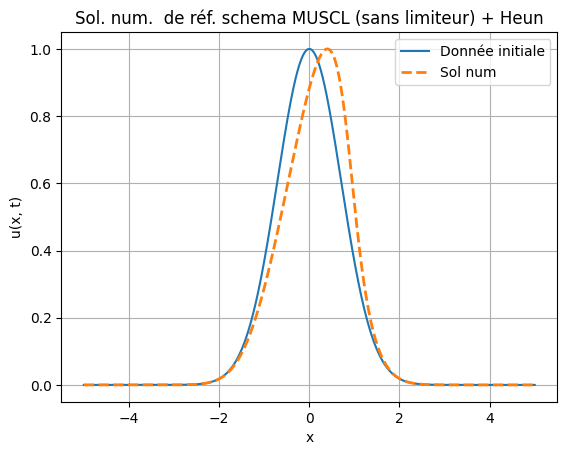

In [ ]:
T = 0.4
N_ref= 10000
x_ref = np.linspace(-5, 5, N_ref+1)
dt_ref = 1e-5
u0 = u_exact(x_ref, 0)
beta = 1./3
u_ref= solve_conv_heun(x_ref, u0, T, dt_ref, beta)
plt.plot(x_ref, u0, label = "Donnée initiale")
plt.plot(x_ref, u_ref,'--', linewidth = 2, label = "Sol num")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. num.  de réf. schema MUSCL (sans limiteur) + Heun")
plt.legend()
plt.grid()
plt.show()

Nb. iter = 801
Nb. iter = 1601
Nb. iter = 2401
Nb. iter = 3201
Nb. iter = 4001
Nb. iter = 4801
Nb. iter = 5601
Nb. iter = 6400
Nb. iter = 7201
Ordre de convergence estimé: 2.01
---------------test--------------------------


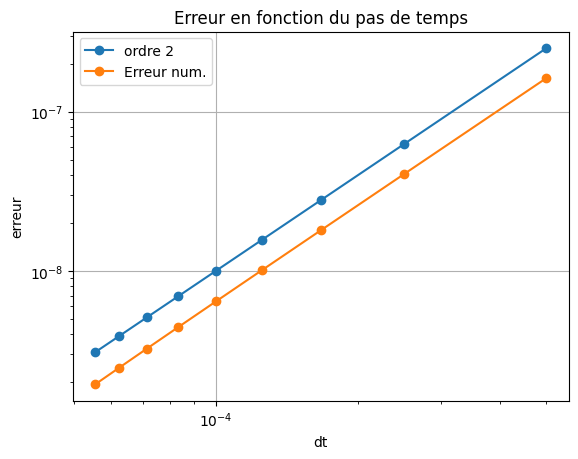

In [ ]:
dt_vals = [1e-3/(2*i) for i in range(1, 10)]
u0 = u_exact(x_ref, 0)
####

vals_erreurs = []

for dt in dt_vals:
    udt = solve_conv_heun(x_ref, u0, T, dt, beta)
    err = np.linalg.norm(u_ref - udt, np.inf)

    vals_erreurs.append(err)


log_dt = np.log(dt_vals)
log_erreurs = np.log(vals_erreurs)

pente, _= np.polyfit(log_dt, log_erreurs, 1)

print(f"Ordre de convergence estimé: {pente:.2f}")
print("---------------test--------------------------")

dt = np.array(dt_vals)
plt.loglog(dt, dt**2, marker ='o', label = "ordre 2")
plt.loglog(dt, vals_erreurs, marker='o', label="Erreur num.")

plt.title("Erreur en fonction du pas de temps")
plt.xlabel('dt')
plt.ylabel('erreur')
plt.legend()
plt.grid(True)
plt.show()

Là on voit bien l'ordre 2 de convergence de la méthode de Heun. Avec une solution manufacturée (avec un terme source qui apparaît dans l'équation), ici j'utilise une solution de réfence calculé sur un pas de temps petit, et je calcule pour différent pas de temps une solution numérique, qui est calculée sur le maillage d'espace que la solution de référence.

Exemple avec Euler amélioré

In [ ]:
def solve_conv_ea(x, u0, T, dt_init, beta):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL
        if t+dt>T:
            dt = T-t

        #####Etape 1 de E.a.
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.zeros_like(u)

        phi = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - 0.5*(dt/dx)*(phi[1:] - phi[:-1])

        #cdt aux bords period.
        u_star[0] = u_star[-1]

        ######Étape 2 de E.a.
        u_new = np.copy(u)
        ul_star, ur_star = muscl_reconstruction_periodic(u_star, beta)
        phi_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N-1)])

        u_new[1:-1] = u[1:-1] - (dt/dx)*(phi_star[1:] - phi_star[:-1])

        #cdt aux bords period.
        u_new[0] = u_new[-1]

        u = u_new
        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

Nb. iter = 40000


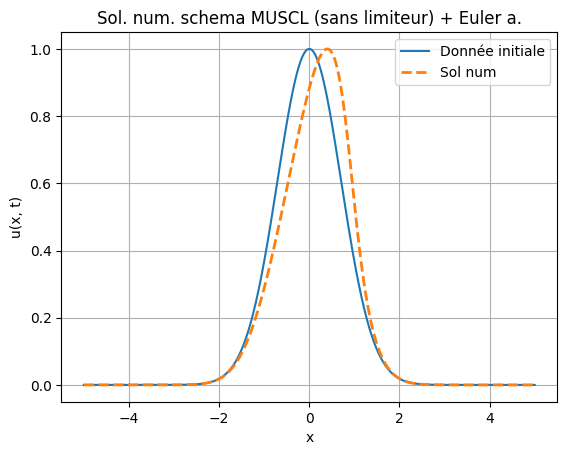

In [ ]:
u0 = u_exact(x_ref, 0)
u_ref_ea= solve_conv_ea(x_ref, u0, T, dt_ref, beta)
plt.plot(x_ref, u0, label = "Donnée initiale")
plt.plot(x_ref, u_ref_ea,'--', linewidth = 2, label = "Sol num")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. num. schema MUSCL (sans limiteur) + Euler a.")
plt.legend()
plt.grid()
plt.show()

Nb. iter = 801
Nb. iter = 1601
Nb. iter = 2401
Nb. iter = 3201
Nb. iter = 4001
Nb. iter = 4801
Nb. iter = 5601
Nb. iter = 6400
Nb. iter = 7201
Ordre de convergence estimé: 2.01
---------------test--------------------------


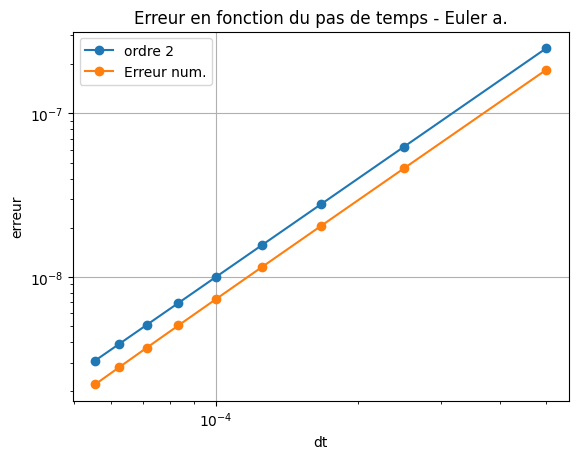

In [ ]:
dt_vals = [1e-3/(2*i) for i in range(1, 10)]
u0 = u_exact(x_ref, 0)
####

vals_erreurs_ea = []

for dt in dt_vals:
    udt = solve_conv_ea(x_ref, u0, T, dt, beta)
    err = np.linalg.norm(u_ref_ea - udt, np.inf)

    vals_erreurs_ea.append(err)


log_dt = np.log(dt_vals)
log_erreurs = np.log(vals_erreurs_ea)

pente1, _= np.polyfit(log_dt, log_erreurs, 1)

print(f"Ordre de convergence estimé: {pente1:.2f}")
print("---------------test--------------------------")

dt = np.array(dt_vals)
plt.loglog(dt, dt**2, marker ='o', label = "ordre 2")
plt.loglog(dt, vals_erreurs_ea, marker='o', label="Erreur num.")

plt.title("Erreur en fonction du pas de temps - Euler a.")
plt.xlabel('dt')
plt.ylabel('erreur')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
def impicit_diffusion(u, dx, dt, nu):
    #Matrice pour la diffusion
    N = len(u)
    r = (nu*dt)/dx**2
    diag = (1+2*r)*np.ones(N)
    hors_diag = -r*np.ones(N-1)
    A = sp.diags([hors_diag, diag, hors_diag], [-1, 0, 1], shape=(N, N), format='csr')

    A[0, -1]=-r #cdt aux bords
    A[-1, 0]= -r #cdt aux bords

    return spla.spsolve(A, u)

In [ ]:
def strang_conv(f, x, u0, T, dt_init, beta, nu):#méthode de splitting de strang
    N = len(x)
    u = np.copy(u0)
    dx = x[1]-x[0]


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt_diff = 0.5*dx**2/nu
        dt = min(dt_init, 0.8*dx/umax, dt_diff) #CFL
        if t+dt>T:
            dt = T-t

        #####Etape 1 de strang (1/2 pas de temps)
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.copy(u)

        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:] - flux[:-1])

        #cdt aux bords periodiques
        u_star[0] = u_star[-1]

        ######Étape 2 de strang (pas de temps complet)
        u_star_star = impicit_diffusion(u_star, dx, dt, nu)  + dt*f(x, t+dt, nu)

        #####Étape 3 de strang (1/2 pas de temps)
        ul1, ur1 = muscl_reconstruction_periodic(u_star_star, beta)
        u_new= np.copy(u_star_star)
        flux_star = np.array([flux_godunov(ul1[i], ur1[i]) for i in range(N-1)])

        u_new[1:-1] = u_star_star[1:-1] - (0.5*dt/dx)*(flux_star[1:] - flux_star[:-1])

        #cdt aux bords periodiques
        u_new[0] = u_new[-1]

        u = u_new
        k+=1
        t+= dt

    print("Nb. iter = ", k)


    return u


In [ ]:
def F(x, t, nu):
    return np.exp(-(x-t)**2)*(2*(x-t) -2*(x-t)*np.exp(-(x-t)**2) - nu*(-2+4*(x-t)**2))


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Nb. iter =  7841


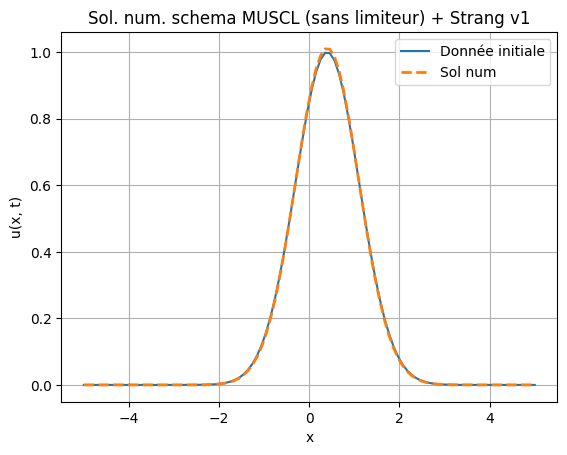

In [ ]:
T = 0.4
dt = 1e-2
x = np.linspace(-5, 5, 100)
u0 = u_exact(x, 0)
nu = 100
beta = 1./3.
u_num = strang_conv(F, x, u0, T, dt, beta, nu)
plt.plot(x, u_exact(x, T), label = "Donnée initiale")
plt.plot(x, u_num,'--', linewidth = 2, label = "Sol num")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. num. schema MUSCL (sans limiteur) + Strang v1")
plt.legend()
plt.grid()
plt.show()

Nb. iter =  160
Nb. iter =  169
Nb. iter =  177
Nb. iter =  185
Nb. iter =  193
Nb. iter =  200
Nb. iter =  209
Nb. iter =  217
Nb. iter =  225
Nb. iter =  232
Ordre de convergence estimé L_inf: 1.04
Ordre de convergence estimé L2: 1.00
---------------test--------------------------


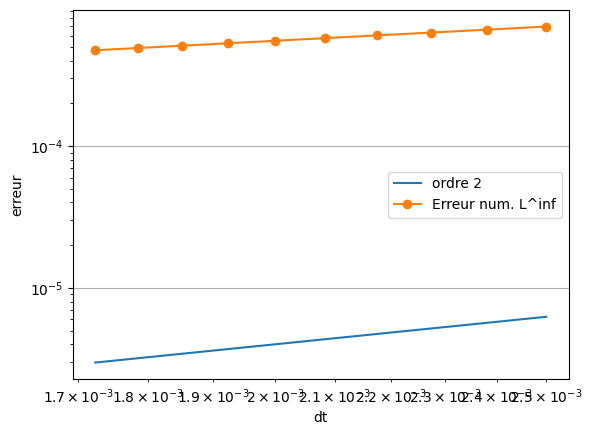

In [ ]:
T = 0.4
N = 1000
x = np.linspace(-5, 5, N+1)
dt_vals = [1e-1/(2*i) for i in range(20, 30)]
u0 = u_exact(x, 0)
uex = u_exact(x, T)
beta = 1./3.
nu = 1e-3
####

vals_erreurs_stg = []
vals_erreurs2 = []
for dt in dt_vals:
    udt = strang_conv(F, x, u0, T, dt, beta, nu)
    err = np.linalg.norm(uex - udt, np.inf)
    err2 = np.sqrt(np.sum((uex - udt)**2))/N
    vals_erreurs_stg.append(err)
    vals_erreurs2.append(err2)


log_dt = np.log(dt_vals)
log_erreurs = np.log(vals_erreurs_stg)
log_erreurs2 = np.log(vals_erreurs2)

pente2, _= np.polyfit(log_dt, log_erreurs, 1)
pente3, _= np.polyfit(log_dt, log_erreurs2, 1)

print(f"Ordre de convergence estimé L_inf: {pente2:.2f}")
print(f"Ordre de convergence estimé L2: {pente3:.2f}")
print("---------------test--------------------------")

dt = np.array(dt_vals)
plt.loglog(dt, dt**2, label = "ordre 2")

plt.loglog(dt, vals_erreurs_stg, marker='o', label="Erreur num. L^inf")
#plt.loglog(dt, vals_erreurs2, marker='o', label="Erreur num. L^2")
#plt.title("Erreur en fonction du pas de temps - Strang")
plt.xlabel('dt')
plt.ylabel('erreur')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
def strg_conv(x, u0, T, dt_init, beta, nu):#méthode de splitting de strang
    N = len(x)
    u = np.copy(u0)
    dx = x[1]-x[0]


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt_diff = 0.5*dx**2/nu
        dt = min(dt_init, 0.8*dx/umax, dt_diff)#CFL
        if t+dt>T:
            dt = T-t

        #####Etape 1 de strang (1/2 pas de temps)
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.copy(u)

        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:] - flux[:-1])

        #cdt aux bords periodiques
        u_star[0] = u_star[-1]

        ######Étape 2 de strang (pas de temps complet)
        u_star_star = impicit_diffusion(u_star, dx, dt, nu)


        #####Étape 3 de strang (1/2 pas de temps)
        ul1, ur1 = muscl_reconstruction_periodic(u_star_star, beta)
        u_new= np.copy(u_star_star)
        flux_star = np.array([flux_godunov(ul1[i], ur1[i]) for i in range(N-1)])

        u_new[1:-1] = u_star_star[1:-1] - (0.5*dt/dx)*(flux_star[1:] - flux_star[:-1])

        #cdt aux bords periodiques
        u_new[0] = u_new[-1]

        u = u_new
        k+=1
        t+= dt

    print("Nb. iter = ", k)


    return u


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Nb. iter =  40000


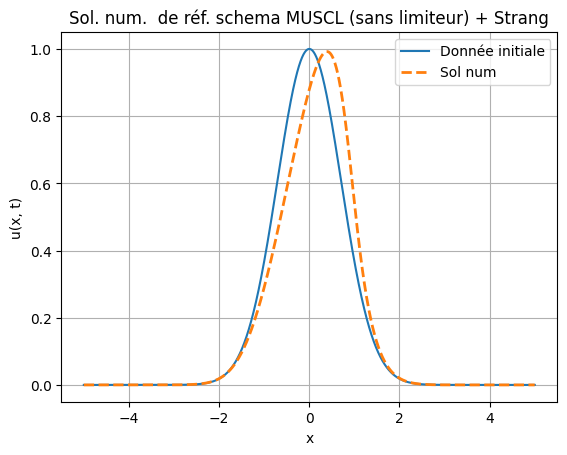

In [10]:
T = 0.4
N_ref= 10000
x_ref1 = np.linspace(-5, 5, N_ref+1)
dt_ref = 1e-5
u0 = u_exact(x_ref1, 0)
beta = 1./3
nu = 1e-2
u_ref1= strg_conv(x_ref1, u0, T, dt_ref, beta, nu)
plt.plot(x_ref1, u0, label = "Donnée initiale")
plt.plot(x_ref1, u_ref1,'--', linewidth = 2, label = "Sol num")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. num.  de réf. schema MUSCL (sans limiteur) + Strang")
plt.legend()
plt.grid()
plt.show()

Nb. iter =  8000
Nb. iter =  8000
Nb. iter =  8000
Nb. iter =  8000
Nb. iter =  8000
Nb. iter =  8000
Nb. iter =  8000
Nb. iter =  8000
Nb. iter =  8000
Nb. iter =  8001
Nb. iter =  8800
Nb. iter =  9601
Nb. iter =  10400
Nb. iter =  11200
Nb. iter =  12001
Nb. iter =  12801
Nb. iter =  13600
Nb. iter =  14400
Nb. iter =  15200
Ordre de convergence estimé: 0.28
---------------test--------------------------


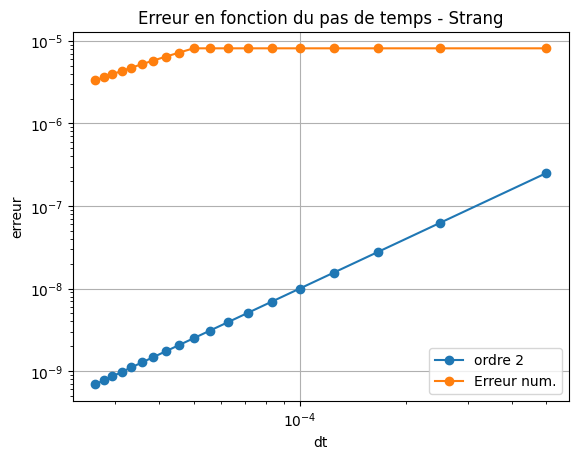

In [ ]:
dt_vals = [1e-3/(2*i) for i in range(1, 20)]
u0 = u_exact(x_ref1, 0)
####

vals_erreurs = []

for dt in dt_vals:
    udt = strg_conv(x_ref1, u0, T, dt, beta, nu)
    err = np.linalg.norm(u_ref1 - udt, np.inf)

    vals_erreurs.append(err)


log_dt = np.log(dt_vals)
log_erreurs = np.log(vals_erreurs)

pente, _= np.polyfit(log_dt, log_erreurs, 1)

print(f"Ordre de convergence estimé: {pente:.2f}")
print("---------------test--------------------------")

dt = np.array(dt_vals)
plt.loglog(dt, dt**2, marker ='o', label = "ordre 2")
plt.loglog(dt, vals_erreurs, marker='o', label="Erreur num.")

plt.title("Erreur en fonction du pas de temps - Strang")
plt.xlabel('dt')
plt.ylabel('erreur')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from matplotlib.ticker import LogLocator, FuncFormatter

Nb. iter =  18400
1
Nb. iter =  19200
2
Nb. iter =  20000
3
Nb. iter =  20800
4
Nb. iter =  21600
5
Ordre de convergence estimé: 2.00
---------------test--------------------------


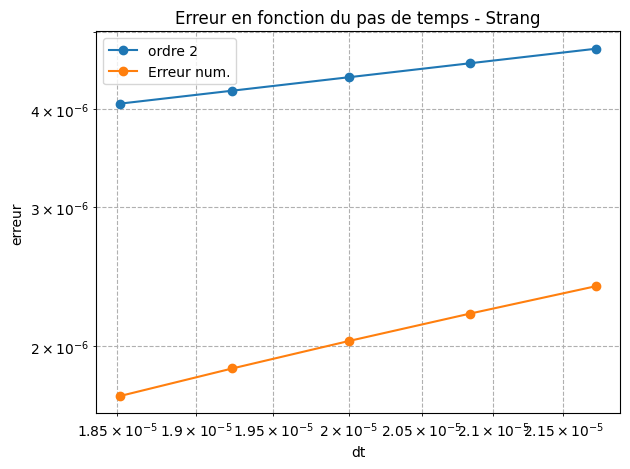

In [12]:
dt_vals = [1e-3/(2*i) for i in range(23, 28)]
T = 0.4
N_ref= 10000
x_ref1 = np.linspace(-5, 5, N_ref+1)
u0 = u_exact(x_ref1, 0)
beta = 1./3
nu = 1e-2
####

vals_erreurs = []
k=0
for dt in dt_vals:
    udt = strg_conv(x_ref1, u0, T, dt, beta, nu)
    err = np.linalg.norm(u_ref1 - udt, np.inf)

    vals_erreurs.append(err)
    k+=1
    print(k)

log_dt = np.log(dt_vals)
log_erreurs = np.log(vals_erreurs)

pente, _= np.polyfit(log_dt, log_erreurs, 1)

print(f"Ordre de convergence estimé: {pente:.2f}")
print("---------------test--------------------------")

dt = np.array(dt_vals)
erreur_ref = 2*vals_erreurs[0]*(dt/dt[0])


plt.figure()
plt.loglog(dt, erreur_ref, marker ='o', label = "ordre 2")
plt.loglog(dt, vals_erreurs, marker='o', label="Erreur num.")

plt.title("Erreur en fonction du pas de temps - Strang")
plt.xlabel('dt')
plt.ylabel('erreur')
plt.legend()
plt.grid(True, which="both", ls="--")

# Choisir les ticks que tu veux afficher
xticks = [dt[0], dt[-1]]  # seulement le premier et le dernier dt
xticks_labels = [f"{dt[0]:.2e}", f"{dt[-1]:.2e}"]

plt.xticks(xticks, xticks_labels, rotation=0)  # pas de rotation nécessaire avec peu de labels

plt.tight_layout()  # Ajuste l'espace pour éviter le chevauchement
plt.savefig('ordre splitting strang.png')
plt.show()